## Modified XGBoost code: single-model training with dynamic landmark evaluation

   Landmark (Visit Number)  Number of Patients (Test) Mortality (%)  \
0                        1                       4022         14.4%   
1                        2                       4022         14.4%   
2                        3                       4022         14.4%   

   AUC XGBoost  AUC Lower CI  AUC Upper CI  
0     0.812556      0.796179      0.829842  
1     0.843221      0.827510      0.858888  
2     0.927081      0.914349      0.938127  


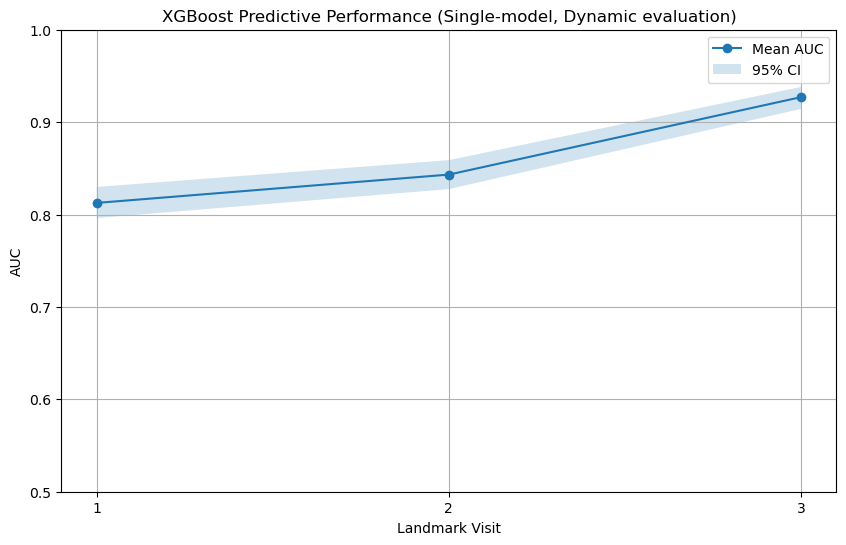

In [1]:
# Modified XGBoost code: single-model training with dynamic landmark evaluation

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack

# Function to calculate bootstrapped confidence intervals
def bootstrap_auc_ci(y_true, y_pred, n_bootstraps=1000, ci=95, seed=42):
    rng = np.random.RandomState(seed)
    bootstrapped_scores = []

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = roc_auc_score(y_true[indices], y_pred[indices])
        bootstrapped_scores.append(score)

    lower_bound = np.percentile(bootstrapped_scores, (100 - ci) / 2)
    upper_bound = np.percentile(bootstrapped_scores, 100 - (100 - ci) / 2)
    
    return lower_bound, upper_bound

# Load dataset
landmark_df = pd.read_csv("landmark_df.csv")

max_visits = 3  # or adjust accordingly

visit_counts = landmark_df['subject_id'].value_counts()
selected_patients = visit_counts[visit_counts == max_visits].index

# Select patients with the specified number of visits
df_selected = landmark_df[landmark_df['subject_id'].isin(selected_patients)].copy()

numeric_features = ['age_at_landmark', 'landmark_visit', 'num_total_visits', 'days_since_previous_visit', 'gender_numeric']

# Split patients (not rows) once for train/test
patients = df_selected['subject_id'].unique()
train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42, stratify=df_selected.groupby('subject_id')['death_in_90days'].max())

train_df = df_selected[df_selected['subject_id'].isin(train_patients)].copy()
test_df = df_selected[df_selected['subject_id'].isin(test_patients)].copy()

# Vectorize texts once for full dataset
med_vectorizer = CountVectorizer(max_features=1000, min_df=1)
diag_vectorizer = CountVectorizer(max_features=1000, min_df=1)
proc_vectorizer = CountVectorizer(max_features=1000, min_df=1)

train_med_vec = med_vectorizer.fit_transform(train_df['med_text'])
test_med_vec = med_vectorizer.transform(test_df['med_text'])

train_diag_vec = diag_vectorizer.fit_transform(train_df['diag_text'])
test_diag_vec = diag_vectorizer.transform(test_df['diag_text'])

train_proc_vec = proc_vectorizer.fit_transform(train_df['proc_text'])
test_proc_vec = proc_vectorizer.transform(test_df['proc_text'])

X_train_numeric = train_df[numeric_features].values
X_test_numeric = test_df[numeric_features].values

X_train = hstack([train_med_vec, train_diag_vec, train_proc_vec, X_train_numeric])
X_test = hstack([test_med_vec, test_diag_vec, test_proc_vec, X_test_numeric])

y_train = train_df['death_in_90days'].values
y_test = test_df['death_in_90days'].values

# Train a single XGBoost model
model = xgb.XGBClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

results = []

# Dynamically evaluate at each landmark
for landmark_visit in range(1, max_visits + 1):
    test_subset = test_df[test_df['landmark_visit'] == landmark_visit].copy()

    if test_subset.empty or len(np.unique(test_subset['death_in_90days'])) < 2:
        continue

    test_med_vec_lm = med_vectorizer.transform(test_subset['med_text'])
    test_diag_vec_lm = diag_vectorizer.transform(test_subset['diag_text'])
    test_proc_vec_lm = proc_vectorizer.transform(test_subset['proc_text'])

    X_test_numeric_lm = test_subset[numeric_features].values
    X_test_lm = hstack([test_med_vec_lm, test_diag_vec_lm, test_proc_vec_lm, X_test_numeric_lm])

    y_test_lm = test_subset['death_in_90days'].values

    y_pred_proba = model.predict_proba(X_test_lm)[:, 1]
    auc = roc_auc_score(y_test_lm, y_pred_proba)
    lower_ci, upper_ci = bootstrap_auc_ci(y_test_lm, y_pred_proba)

    mortality_rate = np.mean(y_test_lm) * 100
    num_patients = len(test_subset)

    results.append({
        'Landmark (Visit Number)': landmark_visit,
        'Number of Patients (Test)': num_patients,
        'Mortality (%)': f"{mortality_rate:.1f}%",
        'AUC XGBoost': auc,
        'AUC Lower CI': lower_ci,
        'AUC Upper CI': upper_ci
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Plot
x = results_df['Landmark (Visit Number)']
y = results_df['AUC XGBoost']
y_lower = results_df['AUC Lower CI']
y_upper = results_df['AUC Upper CI']

plt.figure(figsize=(10, 6))
plt.plot(x, y, linestyle='-', linewidth=1.5, marker='o', label='Mean AUC')
plt.fill_between(x, y_lower, y_upper, alpha=0.2, label='95% CI')

plt.title('XGBoost Predictive Performance (Single-model, Dynamic evaluation)')
plt.xlabel('Landmark Visit')
plt.ylabel('AUC')
plt.xticks(x)
plt.ylim(0.5, 1.0)
plt.grid(True)
plt.legend()
plt.show()
